# Part I: step 1

In [ ]:
# the matrices
import numpy as np
import pandas as pd

# Define classes
classes = ["A", "B", "C", "D", "E"]

# 1. Define original data matrices (5 x n)
model1_data = np.array(
    [
        [0.971, 0.040, -0.046, 0.141, -0.159],
        [0.988, 0.017, -0.068, 0.073, -0.131],
        [0.102, 0.155, 0.973, -0.084, 0.090],
        [0.089, 0.992, -0.031, -0.067, -0.072],
        [0.144, 0.975, -0.027, -0.061, -0.142],
    ]
)

model2_data = np.array(
    [
        [-0.267, -0.215, -0.032, -0.088, -0.189, -0.895, -0.175],
        [0.113, 0.293, 0.401, 0.783, -0.137, -0.260, -0.097],
        [0.932, -0.072, -0.073, -0.188, 0.236, 0.079, 0.089],
        [0.067, -0.087, 0.185, -0.157, -0.179, 0.122, 0.955],
        [-0.130, -0.115, -0.076, -0.042, -0.094, -0.083, -0.979],
    ]
)

brain_data = np.array(
    [
        [0.981, -0.066, -0.045, -0.140, 0.058, 0.005, 0.060, -0.016, -0.095],
        [0.974, -0.042, -0.055, -0.179, 0.050, 0.049, 0.014, 0.035, -0.087],
        [0.100, 0.138, 0.960, -0.084, 0.089, -0.022, -0.096, -0.079, -0.145],
        [0.051, 0.990, -0.099, -0.016, 0.003, -0.067, -0.032, -0.003, -0.086],
        [0.077, 0.986, -0.094, -0.042, 0.013, -0.067, -0.036, -0.037, -0.097],
    ]
)

In [ ]:
#RDM for model 1 and 2
import math
def rdm(data):
  n = data.shape[0]
  rdm = np.zeros((n, n))
  for i in range(n):
    for j in range(n):
      rdm[i, j] = math.sqrt((np.sum((data[i] - data[j])**2)))
  return rdm

rdm_m1 = pd.DataFrame(rdm(model1_data), index=classes, columns=classes)
rdm_m2 = pd.DataFrame(rdm(model2_data), index=classes, columns=classes)
rdm_b = pd.DataFrame(rdm(brain_data), index=classes, columns=classes)
print(rdm_m1)
print(rdm_m2)
print(rdm_b)

          A         B         C         D         E
A  0.000000  0.081915  1.385414  1.317303  1.264756
B  0.081915  0.000000  1.400432  1.335394  1.284468
C  1.385414  1.400432  0.000000  1.317303  1.314731
D  1.317303  1.335394  1.317303  0.000000  0.090918
E  1.264756  1.284468  1.314731  0.090918  0.000000
          A         B         C         D         E
A  0.000000  1.326879  1.633624  1.578315  1.160864
B  1.326879  0.000000  1.503379  1.526815  1.394550
C  1.633624  1.503379  0.000000  1.319092  1.557814
D  1.578315  1.526815  1.319092  0.000000  1.977510
E  1.160864  1.394550  1.557814  1.977510  0.000000
          A         B         C         D         E
A  0.000000  0.095011  1.365076  1.419595  1.397424
B  0.095011  0.000000  1.367680  1.401672  1.379961
C  1.365076  1.367680  0.000000  1.370104  1.359331
D  1.419595  1.401672  1.370104  0.000000  0.052783
E  1.397424  1.379961  1.359331  0.052783  0.000000


In [ ]:
import numpy as np


def upper_triangle(rdm) -> np.ndarray:
    """Extract the off-diagonal upper-triangular entries of an RDM as a 1D vector."""
    rdm_arr = np.asarray(rdm)  # Converts DataFrame to NumPy array safely
    return rdm_arr[np.triu_indices(rdm_arr.shape[0], k=1)]


def lower_triangle(rdm) -> np.ndarray:
    """Extract the off-diagonal lower-triangular entries of an RDM as a 1D vector."""
    rdm_arr = np.asarray(rdm)  # Converts DataFrame to NumPy array safely
    return rdm_arr[np.tril_indices(rdm_arr.shape[0], k=-1)]


def compare_rdms(rdm_a, rdm_b) -> float:
    """Compare two RDMs via Pearson correlation of their upper-triangular entries."""
    vec_a = upper_triangle(rdm_a)
    vec_b = upper_triangle(rdm_b)

    return np.corrcoef(vec_a, vec_b)[0, 1]

In [ ]:
print(compare_rdms(rdm_m1, rdm_b))
print(compare_rdms(rdm_m2, rdm_b))
print(compare_rdms(rdm_m1, rdm_m2))

0.9951260881781725
-0.38051430486797383
-0.3292408739238437


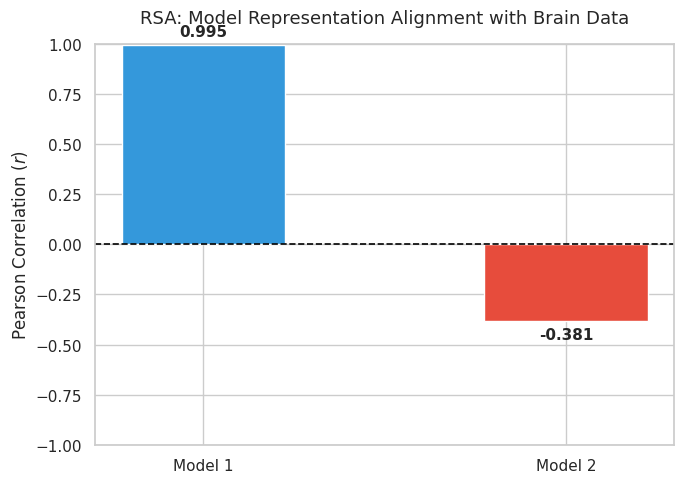

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Compute correlations with the Brain RDM
corr_m1_brain = compare_rdms(rdm_m1, rdm_b)
corr_m2_brain = compare_rdms(rdm_m2, rdm_b)

# Setup data
models = ["Model 1", "Model 2"]
correlations = [corr_m1_brain, corr_m2_brain]

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# Create bar plot
bars = plt.bar(models, correlations, color=["#3498db", "#e74c3c"], width=0.45)

# Add horizontal line at y = 0
plt.axhline(0, color="black", linewidth=1.2, linestyle="--")

# Dynamically place value labels above positive bars and below negative bars
for bar in bars:
    height = bar.get_height()
    va_position = "bottom" if height >= 0 else "top"
    offset = 0.03 if height >= 0 else -0.03

    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + offset,
        f"{height:.3f}",
        ha="center",
        va=va_position,
        fontsize=11,
        fontweight="bold",
    )

# Formatting axis to show full correlation range [-1, 1]
plt.ylabel("Pearson Correlation ($r$)", fontsize=12)
plt.title(
    "RSA: Model Representation Alignment with Brain Data",
    fontsize=13,
    pad=15,
)
plt.ylim(-1.0, 1.0)  # Standard correlation bounds from -1 to +1

plt.tight_layout()
plt.show()

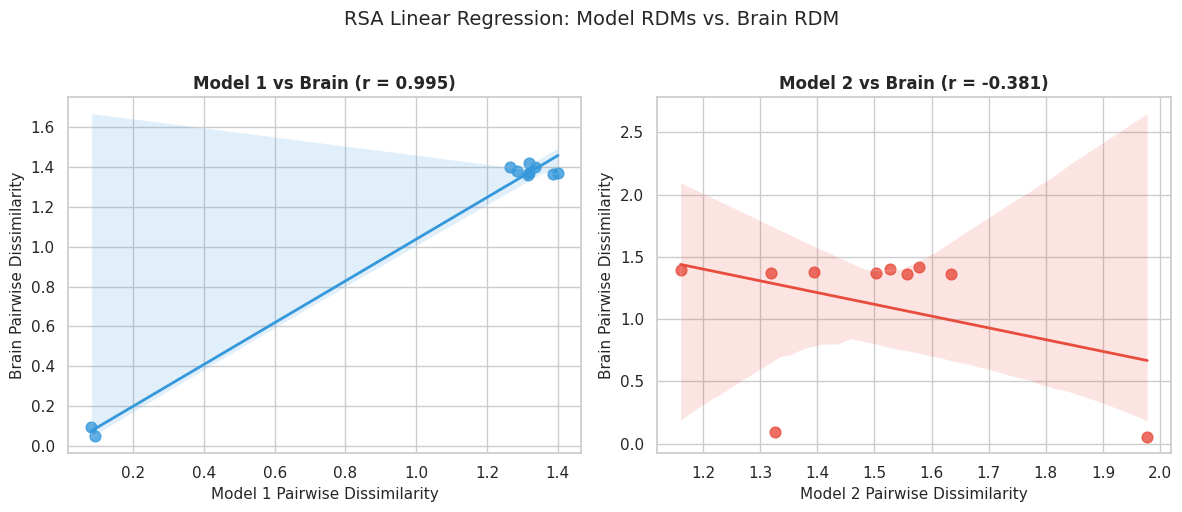

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Extract 1D off-diagonal upper-triangle vectors (10 pairwise distance values each)
vec_m1 = upper_triangle(rdm_m1)
vec_m2 = upper_triangle(rdm_m2)
vec_brain = upper_triangle(rdm_b)

# Calculate Pearson r
r_m1 = compare_rdms(rdm_m1, rdm_b)
r_m2 = compare_rdms(rdm_m2, rdm_b)

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Model 1 vs Brain
sns.regplot(
    x=vec_m1,
    y=vec_brain,
    ax=axes[0],
    color="#3498db",
    scatter_kws={"s": 60, "alpha": 0.8},
    line_kws={"linewidth": 2},
)
axes[0].set_title(
    f"Model 1 vs Brain (r = {r_m1:.3f})", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Model 1 Pairwise Dissimilarity", fontsize=11)
axes[0].set_ylabel("Brain Pairwise Dissimilarity", fontsize=11)

# Plot 2: Model 2 vs Brain
sns.regplot(
    x=vec_m2,
    y=vec_brain,
    ax=axes[1],
    color="#e74c3c",
    scatter_kws={"s": 60, "alpha": 0.8},
    line_kws={"linewidth": 2},
)
axes[1].set_title(
    f"Model 2 vs Brain (r = {r_m2:.3f})", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Model 2 Pairwise Dissimilarity", fontsize=11)
axes[1].set_ylabel("Brain Pairwise Dissimilarity", fontsize=11)

plt.suptitle(
    "RSA Linear Regression: Model RDMs vs. Brain RDM", fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

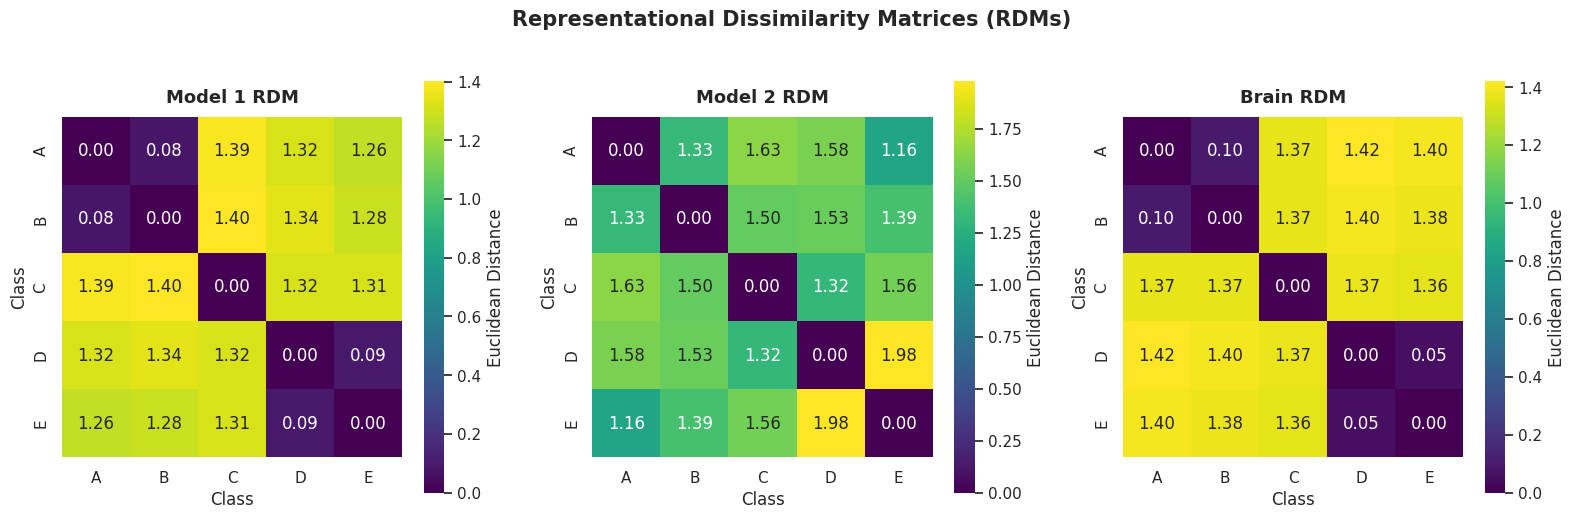

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

classes = ["A", "B", "C", "D", "E"]

# Compute 5x5 distance matrices for each system

# Setup subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.set_theme(style="white")

rdms = [rdm_m1, rdm_m2, rdm_b]
titles = ["Model 1 RDM", "Model 2 RDM", "Brain RDM"]

# Plot heatmaps side-by-side
for i, (rdm, title) in enumerate(zip(rdms, titles)):
    sns.heatmap(
        rdm,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        xticklabels=classes,
        yticklabels=classes,
        ax=axes[i],
        cbar_kws={"label": "Euclidean Distance"},
        square=True,
    )
    axes[i].set_title(title, fontsize=13, fontweight="bold", pad=10)
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel("Class")

plt.suptitle(
    "Representational Dissimilarity Matrices (RDMs)",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_705/1587714115.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_705/1587714115.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


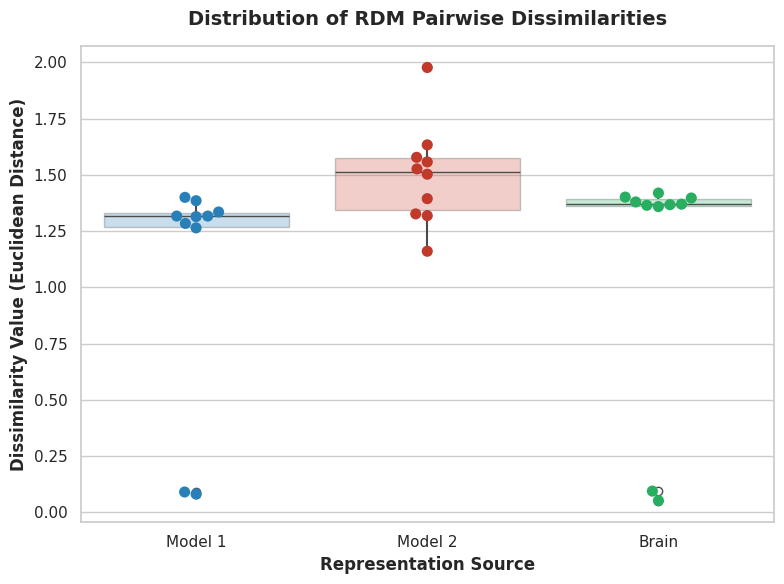

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Extract 1D upper-triangular vectors (pairwise dissimilarities)
vec_m1 = upper_triangle(rdm_m1)
vec_m2 = upper_triangle(rdm_m2)
vec_brain = upper_triangle(rdm_b)

# 2. Combine into a Long-Format DataFrame for Seaborn
df_swarm = pd.DataFrame(
    {
        "Model 1": vec_m1,
        "Model 2": vec_m2,
        "Brain": vec_brain,
    }
).melt(var_name="Source", value_name="Pairwise Dissimilarity")

# 3. Create Swarm Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Swarmplot overlaid on a light boxplot/violinplot for distribution context
sns.boxplot(
    data=df_swarm,
    x="Source",
    y="Pairwise Dissimilarity",
    palette=["#3498db", "#e74c3c", "#2ecc71"],
    boxprops=dict(alpha=0.3),
    showcaps=False,
    whiskerprops={"linewidth": 1.5},
)

sns.swarmplot(
    data=df_swarm,
    x="Source",
    y="Pairwise Dissimilarity",
    palette=["#2980b9", "#c0392b", "#27ae60"],
    size=8,
)

# 4. Formatting
plt.title(
    "Distribution of RDM Pairwise Dissimilarities", fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Representation Source", fontsize=12, fontweight="bold")
plt.ylabel("Dissimilarity Value (Euclidean Distance)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()